In [137]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import GridSearchCV

import seaborn as sns

# For feature transformation
from sklearn.preprocessing import StandardScaler

# For random forest
from sklearn.ensemble import RandomForestRegressor

# For plot
import matplotlib.pyplot as plt

# For decision tree accuracy score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# For decision tree
from sklearn.tree import DecisionTreeClassifier

# For feature selection
from sklearn.feature_selection import SelectKBest, chi2

# For regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set pandas display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Set the maximum display width (e.g., 100 characters)
pd.set_option('display.width', 100) 

# Ensure column width is also constrained
pd.set_option('display.max_colwidth', 80)

import warnings

# Ignore all future warnings globally
warnings.filterwarnings("ignore")

The Titanic Dataset 

The analysis will use the well-known Titanic dataset, which includes 12 variables and 1308 rows in the dataset. Passenger ID, survival (binary: 0=No, 1=Yes), pclass (Ticket class 1=1st, 2=2nd, 3=3rd), name, sex, age, sibsp (number of siblings + spouses aboard the Titanic), parch (number of parents + children aboard the Titanic), ticket (number), fare , cabin (number), embarked (Port of Embarkation: C=Cherbourg, Q=Queenstown, S=Southampton). The dataset was provided pre-split into training and test datasets for model creation and testing on unseen data.

In [138]:
url_2 = "https://raw.githubusercontent.com/Jess-O45/GROUP_PROJECT/main/train.csv"
titanic = train = pd.read_csv(url_2, encoding="latin1")  # or utf-8 if latin1 fails

train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [139]:
titanic.shape # (rows, columns)

(891, 12)

In [140]:
titanic.isna().sum() # Check for missing values in each column

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Cleaning Steps

In [141]:
# Drop columns with low prediction value or too many missing values

# Drop Cabin
titanic = titanic.drop(columns=['Cabin']) # Too many missing values in Cabin column (~77%)

# Drop PassengerId
titanic = titanic.drop(columns=['PassengerId']) # PassengerId not useful for prediction

# Drop Name
titanic = titanic.drop(columns=['Name']) # Name not useful for prediction

# Drop Ticket
titanic = titanic.drop(columns=['Ticket']) # Ticket not useful for prediction

# Drop missing Embarked
titanic = titanic[titanic['Embarked'].notna()]

In [142]:
"""
Group children and adults separately based on 1/0 
Parch (parent on board) or age is less than 18
"""

# Feature engineering 
# Create flag: 1 = child (has parent aboard or under 18), 0 = adult
titanic['ChildFlag'] = np.where((titanic['Age'] < 18) | (titanic['Parch'] > 0), 1, 0)

# Compute mean age by child/adult group (excluding NaNs)
avg_age = titanic.groupby('ChildFlag')['Age'].mean()

# Fill missing ages using group averages
titanic['Age'] = titanic.apply(
    lambda row: avg_age[row['ChildFlag']] if pd.isna(row['Age']) else row['Age'], axis=1)

In [143]:
# Create a new column for total family size
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1

# Add a family size category
titanic['FamilyCategory'] = pd.cut(titanic['FamilySize'],bins=[0, 1, 4, 11],
                                   labels=['Single', 'Small Family', 'Large Family']
                                   )

#titanic.head(10)

In [144]:
titanic.isna().sum()

Survived          0
Pclass            0
Sex               0
Age               0
SibSp             0
Parch             0
Fare              0
Embarked          0
ChildFlag         0
FamilySize        0
FamilyCategory    0
dtype: int64

In [145]:
# Convert categorical variables to numeric using one-hot encoding
titanic = pd.get_dummies(titanic, columns=['Sex', 'Embarked','Pclass', 'FamilyCategory'], drop_first=True)

# Rename Sex_male columnn to Sex
titanic = titanic.rename(columns={'Sex_male': 'Sex'})

titanic = titanic.astype({col: int for col in titanic.select_dtypes(bool).columns})
#titanic.head(10)

In [146]:
# Create correlation matrix for numerical columns

# Keep only numeric columns
numeric_df = titanic.select_dtypes(include=['number'])

# Compute correlation with the target
corr_with_target = numeric_df.corr()['Survived'].sort_values(ascending=False)

corr_with_target

Survived                       1.000000
FamilyCategory_Small Family    0.282510
Fare                           0.255290
ChildFlag                      0.162138
Pclass_2                       0.095002
Parch                          0.083151
FamilySize                     0.018277
Embarked_Q                     0.004536
SibSp                         -0.034040
Age                           -0.078392
FamilyCategory_Large Family   -0.124603
Embarked_S                    -0.151777
Pclass_3                      -0.320171
Sex                           -0.541585
Name: Survived, dtype: float64

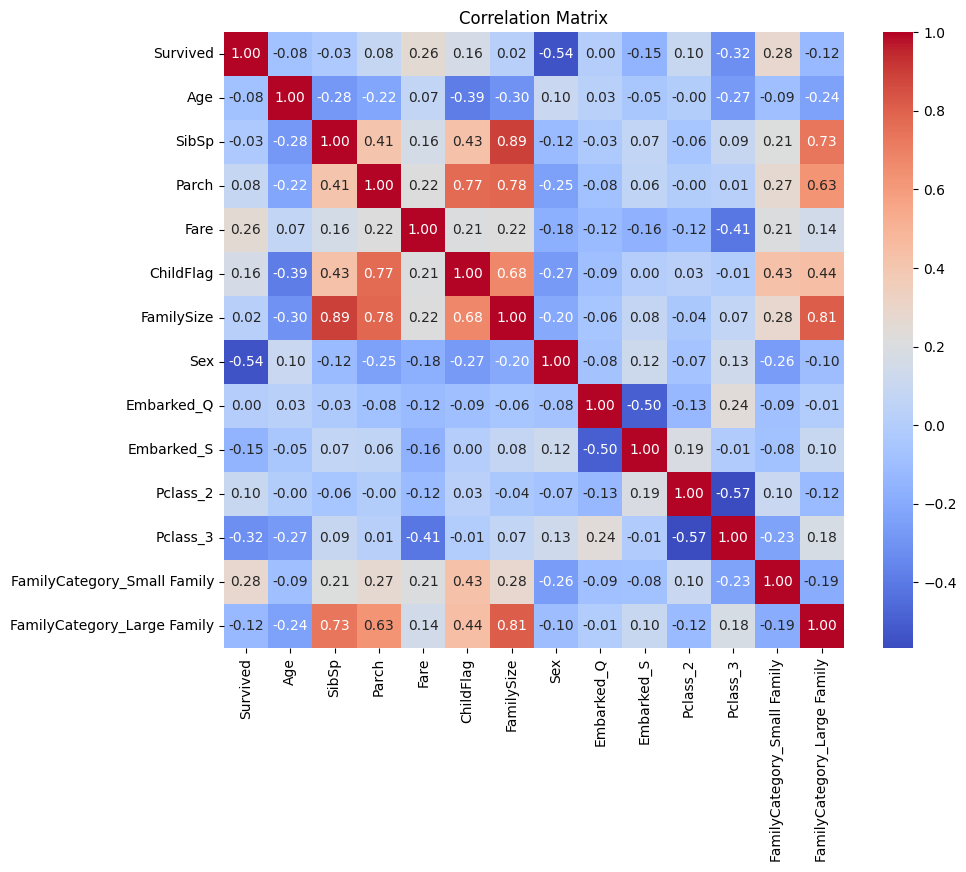

In [147]:
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

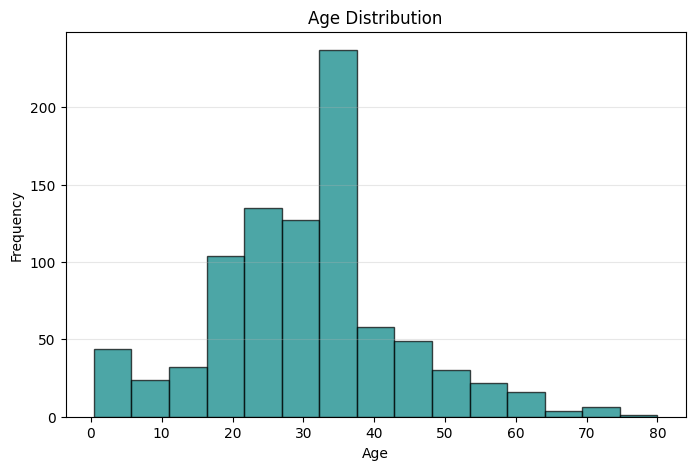

In [148]:
# Make histograms to understand distributions for numeric data

# Age distribution
plt.figure(figsize=(8, 5))
plt.hist(titanic['Age'], bins=15, color='teal', edgecolor='black', alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

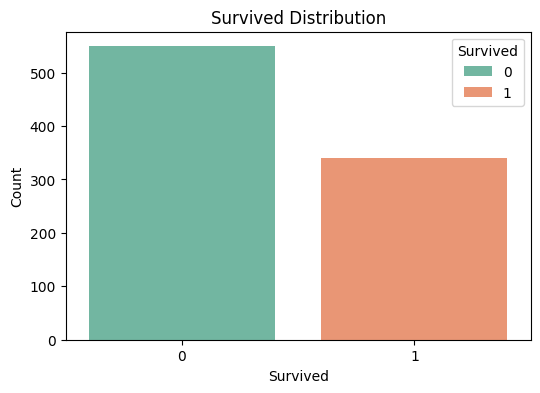

In [149]:
# Make bar charts to understand balance of classes for categorical data
# Survived distribution
plt.figure(figsize=(6, 4)) # Adjusted figure size for better visibility 
sns.countplot(x='Survived', data=titanic, palette='Set2', hue='Survived')
plt.title('Survived Distribution')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# 0 = Died, 1 = Survived

In [150]:
# Split data into features and target
X = titanic.drop('Survived', axis=1) # Features
y = titanic['Survived'] # Target variable

# Split data into test and train sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% train, 20% test

In [151]:
"""
Logistic Regression: A good baseline model for binary classification problems.
It provides a simple, interpretable model to understand feature importance, 
such as the strong correlation between gender and survival.
"""
# Model training and evaluation
model = LogisticRegression(max_iter=1000, # Increase max_iter to ensure convergence
                           class_weight='balanced') # Handle class imbalance
model.fit(X_train, y_train) # Fit the model

y_pred = model.predict(X_test) # Predict on test set

print("Accuracy:", accuracy_score(y_test, y_pred)) 

Accuracy: 0.7696629213483146


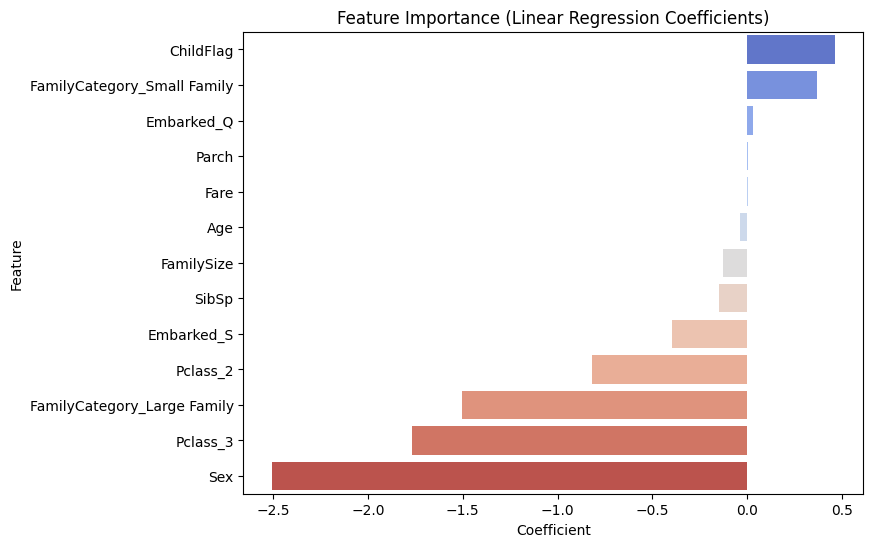

In [152]:

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_.ravel()   # <── flatten to 1D
}).sort_values(by='Coefficient', ascending=False)
 
 
plt.figure(figsize=(8,6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients, palette='coolwarm')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.show()

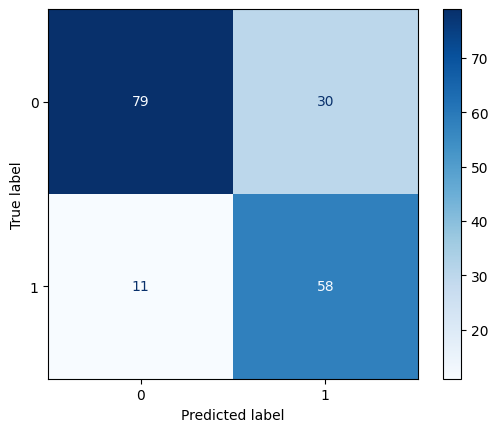


Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.72      0.79       109
           1       0.66      0.84      0.74        69

    accuracy                           0.77       178
   macro avg       0.77      0.78      0.77       178
weighted avg       0.79      0.77      0.77       178



In [153]:
# Confusion Matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred) # Compute confusion matrix 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]) # Create display 
disp.plot(cmap=plt.cm.Blues) # Plot confusion matrix
plt.show() # Show plot

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Random Forest Model

In [154]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # Initialize model
rf_model.fit(X_train, y_train) # Fit Model
y_pred_rf = rf_model.predict(X_test) # Predict

Random Forest Accuracy: 0.7865168539325843


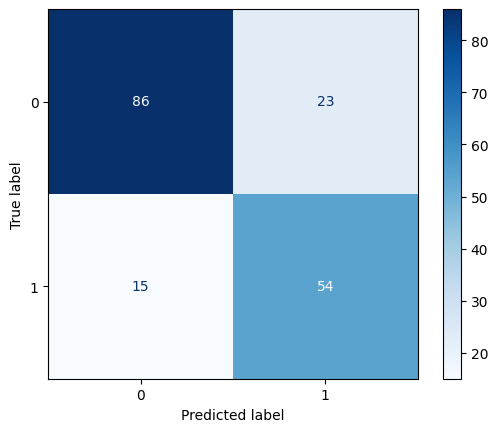


Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.79      0.82       109
           1       0.70      0.78      0.74        69

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.79      0.79      0.79       178



In [155]:
# Calculate accuracy for Random Forest
y_pred_rf_binary = [1 if pred >= 0.5 else 0 for pred in y_pred_rf] # Convert to binary, RF gives probabilities
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf_binary)) # Compute accuracy

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf_binary) # Compute confusion matrix
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[0, 1]) # Create display
disp_rf.plot(cmap=plt.cm.Blues) #  Plot confusion matrix
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_binary))

XGBoost Accuracy: 0.8089887640449438


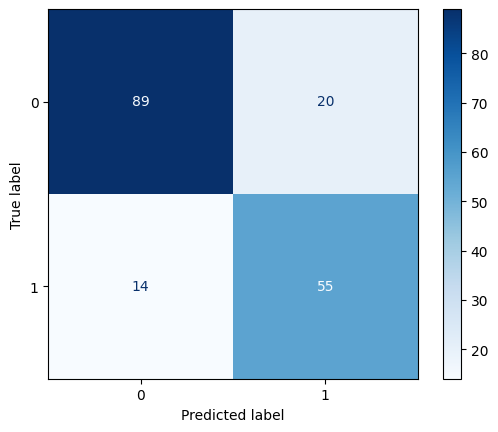


Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84       109
           1       0.73      0.80      0.76        69

    accuracy                           0.81       178
   macro avg       0.80      0.81      0.80       178
weighted avg       0.81      0.81      0.81       178



In [156]:
# Gradient Boosting (e.g., XGBoost):
import xgboost as xgb
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42) # Initialize model
xgb_model.fit(X_train, y_train) # Fit model
y_pred_xgb = xgb_model.predict(X_test) # Predict
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb)) # Compute accuracy

# Confusion Matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb) # Compute confusion matrix
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=[0, 1]) # Create display
disp_xgb.plot(cmap=plt.cm.Blues) # Plot confusion matrix
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

KNN Accuracy: 0.7134831460674157


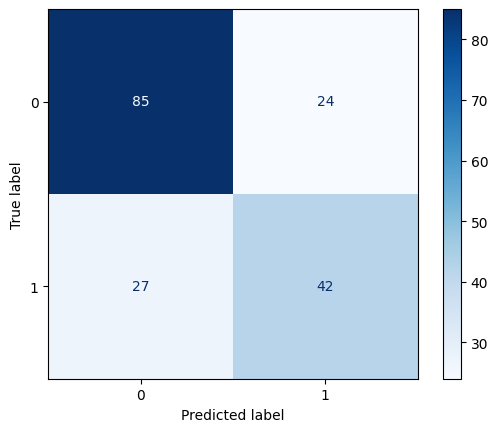


Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.78      0.77       109
           1       0.64      0.61      0.62        69

    accuracy                           0.71       178
   macro avg       0.70      0.69      0.70       178
weighted avg       0.71      0.71      0.71       178



In [157]:
#K-Nearest Neighbors (KNN):
from sklearn.neighbors import KNeighborsClassifier # Import KNN
knn_model = KNeighborsClassifier(n_neighbors=3) # Initialize model K=3
knn_model.fit(X_train, y_train) # Fit model
y_pred_knn = knn_model.predict(X_test) # Predict

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn)) # Compute accuracy

# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn) # Compute confusion matrix
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=[0, 1]) # Create display
disp_knn.plot(cmap=plt.cm.Blues) # Plot confusion matrix
plt.show() # Show plot

print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))